In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data.csv")

**IDENTIFYING DATASET ERRORS:**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           100000 non-null  int64  
 1   city         100000 non-null  object 
 2   timestamp    100000 non-null  object 
 3   temperature  100000 non-null  float64
 4   humidity     100000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.8+ MB


In [6]:
df.describe()

,id,temperature,humidity
count,100000.000000,100000.000000,100000.000000
mean,50000.500000,-9.936993,49.602410
std,28867.657797,141.407020,28.836865
min,1.000000,-999.000000,0.000000
25%,25000.750000,-3.200000,25.000000
50%,50000.500000,9.600000,49.000000
75%,75000.250000,22.400000,75.000000
max,100000.000000,35.000000,99.000000


In [7]:
df['city'].value_counts()

city
Warszawa    19950
Olsztyn     19948
Gdansk      19781
Poznan      19702
Krakow      19588
ERROR        1031
Name: count, dtype: int64

We have found 3 problems:
- wrong data type for timestamp
- impossible values for some temperature measurements
- errors in some city names

In [8]:
#CHANGING TIMESTAMP DATATYPE
df['timestamp'] = pd.to_datetime(df['timestamp'])

#DROPPING CITIES WITH ERROR
df = df.drop(df[df['city'] == 'ERROR'].index)

#REPLACING WRONG TEMPERATURE MEASUREMENTS WITH MEAN FOR GIVEN CITY
df['temperature'] = df['temperature'].replace(-999.0, np.nan)

df['temperature'] = df['temperature'].fillna(df.groupby('city')['temperature'].transform('mean'))

**DATASET IS CLEAR NOW**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98969 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           98969 non-null  int64         
 1   city         98969 non-null  object        
 2   timestamp    98969 non-null  datetime64[ns]
 3   temperature  98969 non-null  float64       
 4   humidity     98969 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.5+ MB


In [10]:
df.describe()

,id,timestamp,temperature,humidity
count,98969.000000,98969,98969.000000,98969.000000
mean,49997.126221,2026-08-29 08:52:08.573280768,10.071064,49.594156
min,1.000000,2026-07-25 15:36:01,-15.000000,0.000000
25%,25001.000000,2026-08-12 00:16:01,-2.200000,25.000000
50%,49999.000000,2026-08-29 08:54:01,10.082950,49.000000
75%,74985.000000,2026-09-15 17:20:01,22.400000,75.000000
max,100000.000000,2026-10-03 02:15:01,35.000000,99.000000
std,28865.678886,NaN,14.304621,28.841659


In [11]:
df['city'].value_counts()

city
Warszawa    19950
Olsztyn     19948
Gdansk      19781
Poznan      19702
Krakow      19588
Name: count, dtype: int64

In [20]:
#APPLYING SOME PATTERNS ON TEMPERATURE AND HUMIDITY SO THE PLOTS WILL BE MORE REALISTIC

#variating temperatures among cities
city_offsets = {
    'Olsztyn': -4.5,
    'Gdansk': -2.0,
    'Warszawa': 0.0,   
    'Poznan': 1.5,
    'Krakow': 4.0
}

df['temperature'] = df['temperature'] + df['city'].map(city_offsets)

#humidity correlated with temperature
df['humidity'] = 100 - (df['temperature'] * 1.5) + np.random.normal(0, 15, len(df))
df['humidity'] = df['humidity'].clip(0, 100)

**NOW WE CAN PLOT OUR RESULTS**

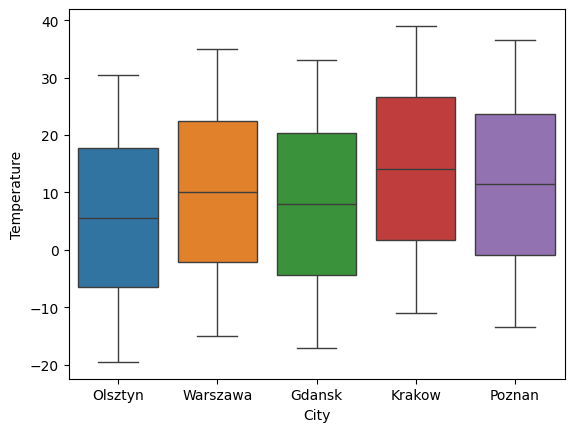

In [19]:
sns.boxplot(data=df, x='city', y='temperature', hue=df['city'])
plt.xlabel('City')
plt.ylabel('Temperature')
plt.show()

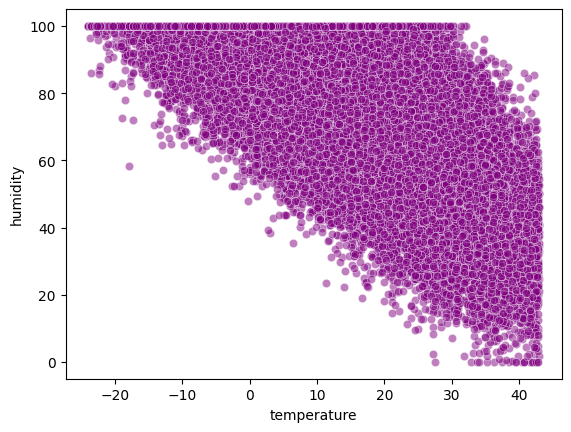

In [22]:
sns.scatterplot(data=df, x='temperature', y='humidity', alpha=0.5, color='purple')
plt.show()

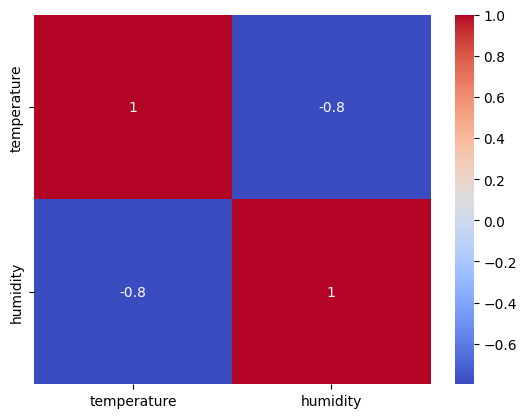

In [21]:
corr_matrix = df[['temperature', 'humidity']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()